# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, log_loss,
                             roc_curve, precision_recall_curve, mean_absolute_error,
                             mean_squared_error, r2_score)
from math import sqrt

df = pd.read_csv(r'C:\Users\rubin\OneDrive\Desktop\AI fellow\week4\WA_Fn-UseC_-Telco-Customer-Churn.csv')

---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [3]:
print('=' * 70)
print('BLOCK 1.1: BASIC INSPECTION')
print('=' * 70)
print(f'Shape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nData types:')
print(df.dtypes)
print(f'\nSummary statistics (numeric):')
print(df.describe())
print(f'\nCategorical columns:')
print(df.describe(include='object'))
print(f'\nMissing values per column:')
print(df.isnull().sum())
print(f'\nTotalCharges dtype: {df["TotalCharges"].dtype}')
print(f'TotalCharges sample values: {df["TotalCharges"].sample(10).tolist()}')
print(f'Unique values in TotalCharges (first 20): {df["TotalCharges"].unique()[:20]}')
print()
print('Each row represents one customer.')
print('Data types: Most categorical columns are object type, tenure/MonthlyCharges are numeric.')
print('TotalCharges is object dtype - likely contains whitespace strings masking as nulls.')

BLOCK 1.1: BASIC INSPECTION
Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

 

---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space):
- y (target variable):
- Probability distribution of y:
- Natural loss function:
- Hypothesis class:
- Assumption 1:
- Assumption 2:
- Assumption 3:
- Sources of uncertainty:

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [4]:
print('\n' + '=' * 70)
print('BLOCK 1.2: PROBLEM FORMULATION')
print('=' * 70)
print("""
X (feature space): All input columns except customerID and Churn:
  - Numeric: tenure, MonthlyCharges, TotalCharges
  - Categorical: gender, SeniorCitizen, Partner, Dependents, PhoneService,
    MultipleLines, InternetService, OnlineSecurity, OnlineBackup,
    DeviceProtection, TechSupport, StreamingTV, StreamingMovies,
    Contract, PaperlessBilling, PaymentMethod

y (target variable): Churn (Yes/No) -> binary classification

Probability distribution of y: Bernoulli distribution (binary outcome)

Natural loss function: Binary cross-entropy (log loss)

Hypothesis class: Linear models (linear decision boundary)

Assumption 1: Linear decision boundary - the log-odds of churn are a linear
    combination of features.
Assumption 2: Features are independent of each other (no perfect multicollinearity).
Assumption 3: Observations are IID (independent and identically distributed).
Assumption 4: No missing data that is systematically biased.

Sources of uncertainty:
  - Sampling noise: 7043 customers may not represent full population
  - Label noise: Churn may be recorded incorrectly (e.g., cancelled but re-subscribed)
  - Missing data: TotalCharges has hidden nulls
  - Biased sampling: Data may over/under-represent certain customer segments
  - Distribution shift: Customer behaviour may have changed since data collection
  - Model misspecification: True relationship may be non-linear
""")


BLOCK 1.2: PROBLEM FORMULATION

X (feature space): All input columns except customerID and Churn:
  - Numeric: tenure, MonthlyCharges, TotalCharges
  - Categorical: gender, SeniorCitizen, Partner, Dependents, PhoneService,
    MultipleLines, InternetService, OnlineSecurity, OnlineBackup,
    DeviceProtection, TechSupport, StreamingTV, StreamingMovies,
    Contract, PaperlessBilling, PaymentMethod

y (target variable): Churn (Yes/No) -> binary classification

Probability distribution of y: Bernoulli distribution (binary outcome)

Natural loss function: Binary cross-entropy (log loss)

Hypothesis class: Linear models (linear decision boundary)

Assumption 1: Linear decision boundary - the log-odds of churn are a linear
    combination of features.
Assumption 2: Features are independent of each other (no perfect multicollinearity).
Assumption 3: Observations are IID (independent and identically distributed).
Assumption 4: No missing data that is systematically biased.

Sources of uncerta

In [5]:
print('=' * 70)
print('BLOCK 1.3: DATA PROFILING & FIXING')
print('=' * 70)

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
null_count = df['TotalCharges'].isnull().sum()
print(f'TotalCharges nulls after conversion: {null_count}')

# Fill null TotalCharges with 0 (tenure=0 customers)
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f'TotalCharges fixed. Now has {df["TotalCharges"].isnull().sum()} nulls.')

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f'Churn distribution:\n{df["Churn"].value_counts()}')
print(f'Churn rate: {df["Churn"].mean():.3f}')

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0])
axes[0].set_title('MonthlyCharges Distribution')
sns.histplot(df['tenure'], kde=True, ax=axes[1])
axes[1].set_title('Tenure Distribution')
sns.histplot(df['TotalCharges'], kde=True, ax=axes[2])
axes[2].set_title('TotalCharges Distribution')
plt.tight_layout()
plt.savefig(r'C:\Users\rubin\OneDrive\Desktop\AI fellow\week4\distributions.png')
plt.close()
print('Distribution plots saved to distributions.png')
print()
print('MonthlyCharges: Bimodal distribution - two customer segments (low/high spenders)')
print('Tenure: Right-skewed - many short-tenure customers, fewer long-tenure')
print('TotalCharges: Bimodal - reflects the MonthlyCharges * tenure interaction')
print('TotalCharges had whitespace strings because customers with tenure=0 had empty values')


BLOCK 1.3: DATA PROFILING & FIXING
TotalCharges nulls after conversion: 11
TotalCharges fixed. Now has 0 nulls.
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 0.265
Distribution plots saved to distributions.png

MonthlyCharges: Bimodal distribution - two customer segments (low/high spenders)
Tenure: Right-skewed - many short-tenure customers, fewer long-tenure
TotalCharges: Bimodal - reflects the MonthlyCharges * tenure interaction
TotalCharges had whitespace strings because customers with tenure=0 had empty values


---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [6]:
print('\n' + '=' * 70)
print('BLOCK 1.4: NAIVE BASELINE')
print('=' * 70)

X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X, y)
y_pred_dummy = dummy.predict(X)

print(f'Class distribution:\n{df["Churn"].value_counts(normalize=True)}')
print(f'Naive baseline accuracy: {accuracy_score(y, y_pred_dummy):.4f}')
print(f'Naive baseline recall: {recall_score(y, y_pred_dummy):.4f}')
print(f'Naive baseline F1: {f1_score(y, y_pred_dummy):.4f}')
print()
print('The naive baseline achieves 73% accuracy but 0% recall for churners.')
print('It catches NO churners - completely useless to the business.')
print('Any real model must beat this baseline on recall and F1, not just accuracy.')
print()
print('Manager discussion: A model with 73% accuracy that catches zero churners')
print('is worthless. The first question: "What is the recall for churners?"')


BLOCK 1.4: NAIVE BASELINE
Class distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64
Naive baseline accuracy: 0.7346
Naive baseline recall: 0.0000
Naive baseline F1: 0.0000

The naive baseline achieves 73% accuracy but 0% recall for churners.
It catches NO churners - completely useless to the business.
Any real model must beat this baseline on recall and F1, not just accuracy.

Manager discussion: A model with 73% accuracy that catches zero churners
is worthless. The first question: "What is the recall for churners?"


---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [48]:
print('\n' + '=' * 70)
print('BLOCK 2: PREPROCESSING')
print('=' * 70)

# Drop customerID
X = df.drop(columns=['Churn', 'customerID'])

# One-hot encode categorical features
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f'Features after one-hot encoding: {X_encoded.shape[1]}')
print(f'NaN values in X_encoded: {X_encoded.isnull().sum().sum()}')

# Stratified split: 70/15/15
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, stratify=y_temp, random_state=42
)
print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

# Scale numeric features
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train_s = X_train.copy()
X_val_s = X_val.copy()
X_test_s = X_test.copy()
X_train_s[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_s[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_s[numeric_cols] = scaler.transform(X_test[numeric_cols])
print('Numeric features scaled (fit on train only).')
print('Stratified splitting preserves churn rate across folds.')
print('Scaler fit on training data only to prevent data leakage.')


BLOCK 2: PREPROCESSING
Features after one-hot encoding: 30
NaN values in X_encoded: 0
Train: 4929, Val: 1057, Test: 1057
Train churn rate: 0.265, Val: 0.266, Test: 0.265
Numeric features scaled (fit on train only).
Stratified splitting preserves churn rate across folds.
Scaler fit on training data only to prevent data leakage.


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [50]:
print('\n' + '=' * 70)
print('BLOCK 3: CLASSIFICATION EXPERIMENTS')
print('=' * 70)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RidgeClassifier': RidgeClassifier(random_state=42),
    'SGDClassifier': SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_s, y_train)
    elapsed = time.time() - start
    trained_models[name] = model
    print(f'\n{name} trained in {elapsed:.4f}s')

    y_pred = model.predict(X_val_s)

    # Get probabilities / decision scores
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_val_s)[:, 1]
        ll = log_loss(y_val, proba)
    else:
        proba = model.decision_function(X_val_s)
        ll = None

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)

    results.append({
        'Model': name,
        'TrainTime': f'{elapsed:.4f}s',
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4),
        'LogLoss': round(ll, 4) if ll is not None else 'N/A'
    })




BLOCK 3: CLASSIFICATION EXPERIMENTS

LogisticRegression trained in 0.0618s

RidgeClassifier trained in 0.0115s

SGDClassifier trained in 0.0679s


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [51]:
# Comparison table sorted by PR-AUC
results_df = pd.DataFrame(results)
print('\n\nCOMPARISON TABLE (sorted by PR-AUC):')
results_df_sorted = results_df.sort_values('PR-AUC', ascending=False)
print(results_df_sorted.to_string(index=False))




COMPARISON TABLE (sorted by PR-AUC):
             Model TrainTime  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC LogLoss
LogisticRegression   0.0618s    0.7947     0.6416  0.5160 0.5720   0.8298  0.6278  0.4356
   RidgeClassifier   0.0115s    0.7919     0.6393  0.4982 0.5600   0.8224  0.6215     N/A
     SGDClassifier   0.0679s    0.7938     0.6425  0.5053 0.5657   0.8268  0.6120  0.4459


---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


In [52]:
print('\n' + '=' * 70)
print('BLOCK 3.3: ROC AND PR CURVES')
print('=' * 70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, model in trained_models.items():
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_val_s)[:, 1]
    else:
        proba = model.decision_function(X_val_s)

    fpr, tpr, _ = roc_curve(y_val, proba)
    prec_vals, rec_vals, _ = precision_recall_curve(y_val, proba)

    ax1.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val, proba):.3f})')
    ax2.plot(rec_vals, prec_vals, label=f'{name} (PR-AUC={average_precision_score(y_val, proba):.3f})')

ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend(loc='lower right')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(r'C:\Users\rubin\OneDrive\Desktop\AI fellow\week4\roc_pr_curves.png')
plt.close()
print('ROC and PR curves saved to roc_pr_curves.png')
print()
print('PR curve is more informative for imbalanced data because it focuses')
print('on the positive (churn) class, which is the minority.')
print('ROC curve can look optimistic when negatives dominate.')


BLOCK 3.3: ROC AND PR CURVES
ROC and PR curves saved to roc_pr_curves.png

PR curve is more informative for imbalanced data because it focuses
on the positive (churn) class, which is the minority.
ROC curve can look optimistic when negatives dominate.


---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [53]:
print('\n' + '=' * 70)
print('BLOCK 3.4: THRESHOLD TUNING (Top-200 Budget Constraint)')
print('=' * 70)

lr = trained_models['LogisticRegression']
proba_lr = lr.predict_proba(X_val_s)[:, 1]

# Top-200 threshold
sorted_idx = np.argsort(proba_lr)[::-1]
top200_threshold = proba_lr[sorted_idx[199]]
y_pred_top200 = (proba_lr >= top200_threshold).astype(int)

# Default 0.5 threshold
y_pred_05 = (proba_lr >= 0.5).astype(int)

print(f'Top-200 threshold: {top200_threshold:.4f}')
print(f'Default 0.5 threshold flags: {y_pred_05.sum()} customers')
print(f'Top-200 threshold flags: {y_pred_top200.sum()} customers')
print()
print(f'At default threshold (0.5):')
print(f'  Precision: {precision_score(y_val, y_pred_05):.4f}')
print(f'  Recall: {recall_score(y_val, y_pred_05):.4f}')
print(f'  F1: {f1_score(y_val, y_pred_05):.4f}')
print()
print(f'At top-200 threshold ({top200_threshold:.4f}):')
print(f'  Precision: {precision_score(y_val, y_pred_top200):.4f}')
print(f'  Recall: {recall_score(y_val, y_pred_top200):.4f}')
print(f'  F1: {f1_score(y_val, y_pred_top200):.4f}')


BLOCK 3.4: THRESHOLD TUNING (Top-200 Budget Constraint)
Top-200 threshold: 0.5379
Default 0.5 threshold flags: 226 customers
Top-200 threshold flags: 200 customers

At default threshold (0.5):
  Precision: 0.6416
  Recall: 0.5160
  F1: 0.5720

At top-200 threshold (0.5379):
  Precision: 0.6750
  Recall: 0.4804
  F1: 0.5613


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


In [54]:
print('\n' + '=' * 70)
print('BLOCK 3.5: COEFFICIENT INSPECTION')
print('=' * 70)

feature_names = X_train_s.columns
coefs = lr.coef_[0]
coef_series = pd.Series(coefs, index=feature_names)
top10 = coef_series.abs().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette='RdBu_r', legend=False)
plt.title('Top 10 Features by Absolute Coefficient (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig(r'C:\Users\rubin\OneDrive\Desktop\AI fellow\week4\coefficients.png')
plt.close()
print('Coefficient plot saved to coefficients.png')
print()
print('Top 10 features by absolute coefficient:')
for feat, coef in top10.items():
    print(f'  {feat}: {coef:.4f}')

print()
print('Positive coefficients increase churn probability.')
print('Negative coefficients decrease churn probability.')
print('e.g., Contract_Two year has large negative coef -> customers on')
print('two-year contracts are LESS likely to churn. This makes business sense.')
print('Note: pd.get_dummies with drop_first=True drops Contract_Month-to-month,')
print('so Contract_Two year and Contract_One year are interpreted relative to it.')


BLOCK 3.5: COEFFICIENT INSPECTION
Coefficient plot saved to coefficients.png

Top 10 features by absolute coefficient:
  Contract_Two year: 1.3919
  tenure: 1.2864
  InternetService_Fiber optic: 1.0362
  Contract_One year: 0.7496
  TotalCharges: 0.5430
  PhoneService_Yes: 0.4737
  PaperlessBilling_Yes: 0.3872
  PaymentMethod_Electronic check: 0.3647
  TechSupport_Yes: 0.3514
  StreamingMovies_Yes: 0.3205

Positive coefficients increase churn probability.
Negative coefficients decrease churn probability.
e.g., Contract_Two year has large negative coef -> customers on
two-year contracts are LESS likely to churn. This makes business sense.
Note: pd.get_dummies with drop_first=True drops Contract_Month-to-month,
so Contract_Two year and Contract_One year are interpreted relative to it.


---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [55]:
print('\n' + '=' * 70)
print('BLOCK 3.6: BATCH GD vs SGD')
print('=' * 70)

start = time.time()
lr_batch = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
batch_time = time.time() - start

start = time.time()
lr_sgd = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42).fit(X_train_s, y_train)
sgd_time = time.time() - start

proba_batch = lr_batch.predict_proba(X_val_s)[:, 1]
proba_sgd = lr_sgd.predict_proba(X_val_s)[:, 1]

batch_auc = roc_auc_score(y_val, proba_batch)
sgd_auc = roc_auc_score(y_val, proba_sgd)

print(f'LogisticRegression (Batch GD): {batch_time:.4f}s, ROC-AUC: {batch_auc:.4f}')
print(f'SGDClassifier (Stochastic GD): {sgd_time:.4f}s, ROC-AUC: {sgd_auc:.4f}')
print(f'Coefficients close? {np.allclose(lr_batch.coef_, lr_sgd.coef_, atol=0.15)}')
print()
print('Batch GD converges smoothly and deterministically.')
print('SGD is noisier but faster for large datasets.')
print('For 7000 rows, the difference is negligible. SGD preferred for 7M+ rows.')


BLOCK 3.6: BATCH GD vs SGD
LogisticRegression (Batch GD): 0.0547s, ROC-AUC: 0.8298
SGDClassifier (Stochastic GD): 0.0723s, ROC-AUC: 0.8268
Coefficients close? False

Batch GD converges smoothly and deterministically.
SGD is noisier but faster for large datasets.
For 7000 rows, the difference is negligible. SGD preferred for 7M+ rows.


---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [56]:
print('\n' + '=' * 70)
print('BLOCK 4: REGRESSION EXPERIMENTS')
print('=' * 70)

# Target: tenure (Option A - survival time)
y_reg = df['tenure']

# Remove tenure from feature set (can't predict itself)
reg_features = [c for c in X_encoded.columns if c != 'tenure']

# Split reg data (separate split)
X_reg_full, X_reg_test, y_reg_full, y_reg_test = train_test_split(
    X_encoded[reg_features], y_reg, test_size=0.15, random_state=42
)
X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg_full, y_reg_full, test_size=0.15 / 0.85, random_state=42
)

# Scale numeric features (excluding tenure since it's gone)
reg_num_cols = [c for c in numeric_cols if c in reg_features]
X_reg_train_s = X_reg_train.copy()
X_reg_val_s = X_reg_val.copy()
if reg_num_cols:
    X_reg_train_s[reg_num_cols] = scaler.fit_transform(X_reg_train[reg_num_cols])
    X_reg_val_s[reg_num_cols] = scaler.transform(X_reg_val[reg_num_cols])

# Plot target distribution
plt.figure(figsize=(8, 4))
sns.histplot(y_reg_train, kde=True)
plt.title('Tenure Distribution (Regression Target)')
plt.tight_layout()
plt.savefig(r'C:\Users\rubin\OneDrive\Desktop\AI fellow\week4\tenure_distribution.png')
plt.close()
print('Tenure is right-skewed. Most customers have low tenure, few have high tenure.')




BLOCK 4: REGRESSION EXPERIMENTS
Tenure is right-skewed. Most customers have low tenure, few have high tenure.


---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [57]:
# Train regressors
reg_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.01, random_state=42, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000)
}

reg_results = []
trained_regs = {}

for name, model in reg_models.items():
    model.fit(X_reg_train_s, y_reg_train)
    trained_regs[name] = model
    y_pred_reg = model.predict(X_reg_val_s)

    mae = mean_absolute_error(y_reg_val, y_pred_reg)
    rmse = sqrt(mean_squared_error(y_reg_val, y_pred_reg))
    r2 = r2_score(y_reg_val, y_pred_reg)

    reg_results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4)
    })

print('\nRegression Comparison Table:')
print(pd.DataFrame(reg_results).to_string(index=False))


Regression Comparison Table:
           Model    MAE   RMSE     R2
LinearRegression 6.8734 8.9172 0.8687
           Ridge 6.8707 8.9169 0.8687
           Lasso 6.8578 8.9224 0.8686
      ElasticNet 6.8388 8.9391 0.8681


---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern



BLOCK 4.3: RESIDUAL PLOTS


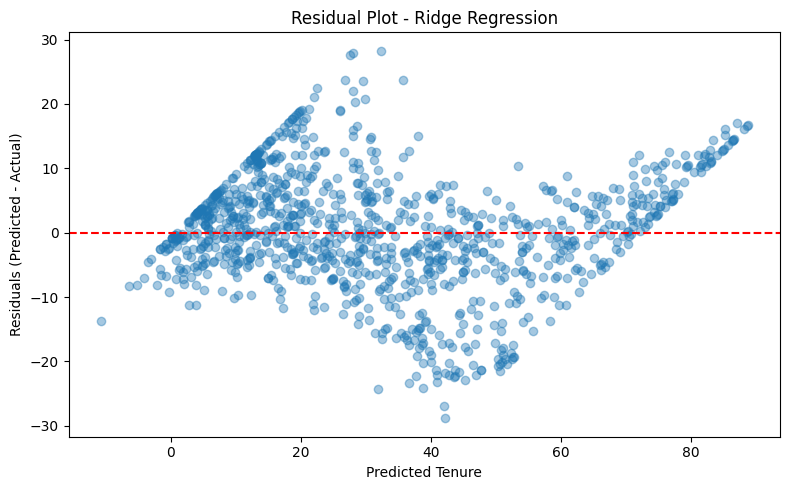

In [60]:
print('\n' + '=' * 70)
print('BLOCK 4.3: RESIDUAL PLOTS')
print('=' * 70)

best_reg = trained_regs['Ridge']
y_pred_best = best_reg.predict(X_reg_val_s)
residuals = y_pred_best - y_reg_val

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Tenure')
plt.ylabel('Residuals (Predicted - Actual)')
plt.title('Residual Plot - Ridge Regression')
plt.tight_layout()
plt.show()



---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs



BLOCK 4.4: REGULARIZATION PATHS


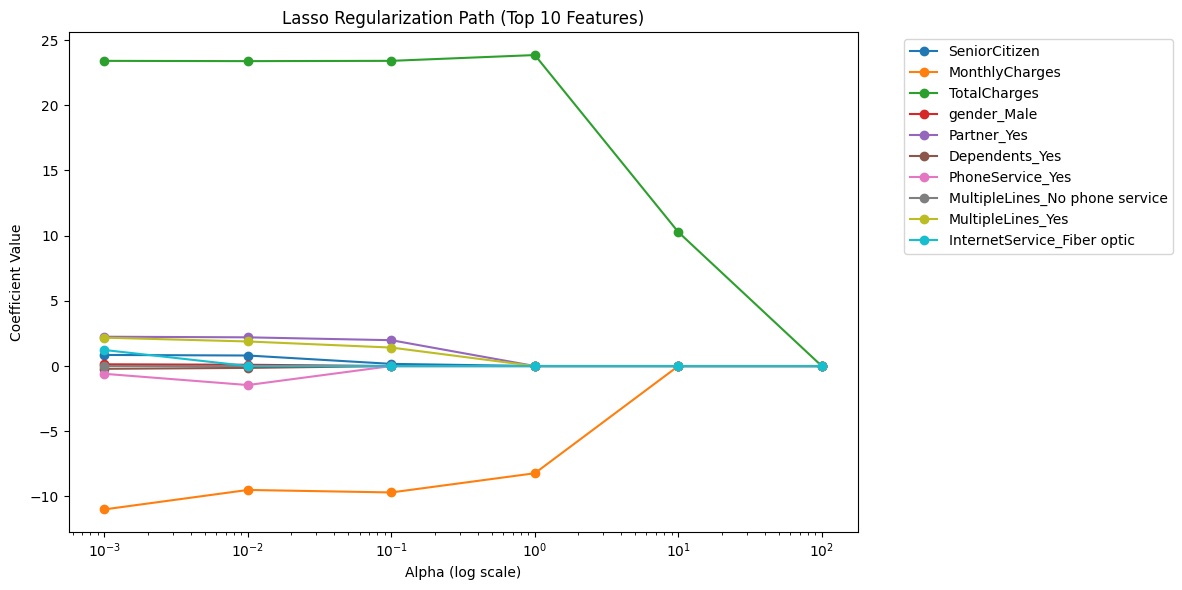

As alpha increases, L1 penalty forces coefficients to exactly zero.
L1 (Lasso) produces sparse solutions due to diamond-shaped constraint region.
L2 (Ridge) shrinks coefficients but never to exactly zero (circular constraint).
Elastic Net combines both: sparse like Lasso, stable like Ridge.


In [61]:
print('\n' + '=' * 70)
print('BLOCK 4.4: REGULARIZATION PATHS')
print('=' * 70)

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
lasso_coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    lasso.fit(X_reg_train_s, y_reg_train)
    lasso_coefs.append(lasso.coef_)

plt.figure(figsize=(12, 6))
for i, feat in enumerate(X_reg_train_s.columns[:10]):
    coef_path = [c[i] for c in lasso_coefs]
    plt.plot(alphas, coef_path, marker='o', label=feat)

plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regularization Path (Top 10 Features)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print('As alpha increases, L1 penalty forces coefficients to exactly zero.')
print('L1 (Lasso) produces sparse solutions due to diamond-shaped constraint region.')
print('L2 (Ridge) shrinks coefficients but never to exactly zero (circular constraint).')
print('Elastic Net combines both: sparse like Lasso, stable like Ridge.')

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [62]:
print('\n' + '=' * 70)
print('BLOCK 4.5: CUSTOMER LIFETIME VALUE (CLV)')
print('=' * 70)

# Get monthly charges - need to align indices between reg split and original data
reg_val_indices = X_reg_val.index
monthly_charges_val = df.loc[reg_val_indices, 'MonthlyCharges'].values
predicted_tenure = np.maximum(best_reg.predict(X_reg_val_s), 0)  # clip negative
clv = monthly_charges_val * predicted_tenure

print(f'Mean CLV: ${clv.mean():.2f}')
print(f'Median CLV: ${np.median(clv):.2f}')
print(f'Std CLV: ${clv.std():.2f}')
print(f'Min CLV: ${clv.min():.2f}')
print(f'Max CLV: ${clv.max():.2f}')
print()
print('CLV tells the business not just WHO might churn, but HOW MUCH value is at risk.')
print('This enables revenue-weighted prioritization - call high-value at-risk customers first.')
print('Negative predicted tenure must be clipped to 0 (impossible to have negative tenure).')


BLOCK 4.5: CUSTOMER LIFETIME VALUE (CLV)
Mean CLV: $2218.40
Median CLV: $1085.34
Std CLV: $2418.34
Min CLV: $0.00
Max CLV: $10292.94

CLV tells the business not just WHO might churn, but HOW MUCH value is at risk.
This enables revenue-weighted prioritization - call high-value at-risk customers first.
Negative predicted tenure must be clipped to 0 (impossible to have negative tenure).


---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [63]:
print('\n' + '=' * 70)
print('BLOCK 5.1: CROSS-VALIDATION')
print('=' * 70)

lr_cv = LogisticRegression(max_iter=1000, random_state=42)
cv_scores = cross_val_score(
    lr_cv, X_train_s, y_train,
    cv=StratifiedKFold(5), scoring='roc_auc'
)
print(f'Stratified 5-fold CV ROC-AUC scores: {cv_scores}')
print(f'Mean CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Holdout validation ROC-AUC: {roc_auc_score(y_val, lr.predict_proba(X_val_s)[:, 1]):.4f}')


BLOCK 5.1: CROSS-VALIDATION
Stratified 5-fold CV ROC-AUC scores: [0.86019818 0.84065149 0.83568281 0.85259742 0.8469047 ]
Mean CV ROC-AUC: 0.8472 ± 0.0086
Holdout validation ROC-AUC: 0.8298


---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA



BLOCK 5.2: LEARNING CURVES


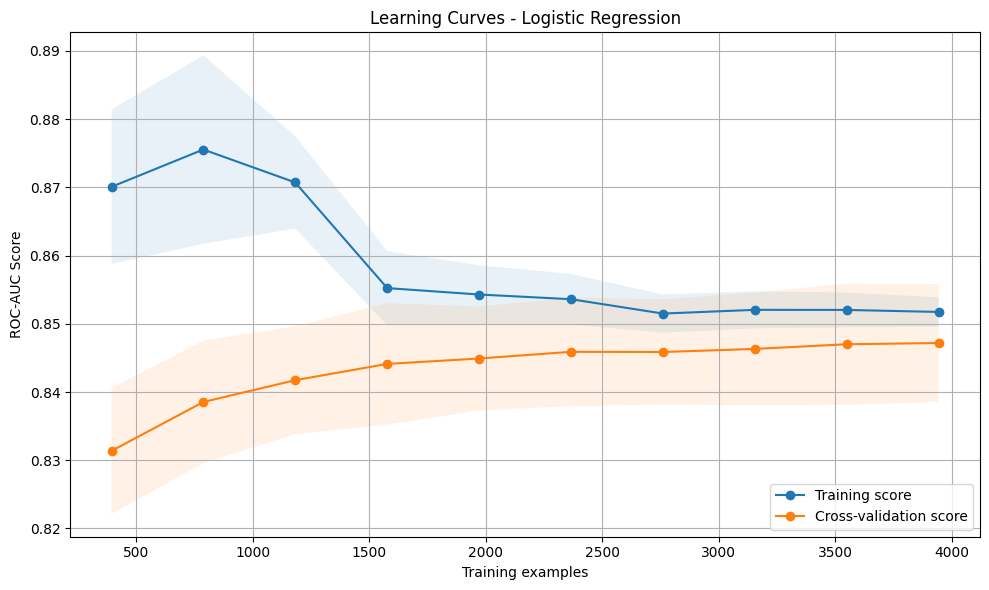

Final training AUC: 0.8517
Final validation AUC: 0.8472
Gap: 0.0046

Model generalizes well - small gap, good absolute performance.


In [65]:
print('\n' + '=' * 70)
print('BLOCK 5.2: LEARNING CURVES')
print('=' * 70)

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_s, y_train,
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.plot(train_sizes, val_mean, 'o-', label='Cross-validation score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
plt.xlabel('Training examples')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curves - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()
print(f'Final training AUC: {train_mean[-1]:.4f}')
print(f'Final validation AUC: {val_mean[-1]:.4f}')
print(f'Gap: {train_mean[-1] - val_mean[-1]:.4f}')
print()
if train_mean[-1] - val_mean[-1] > 0.05:
    print('Model shows some overfitting (gap > 0.05). Consider regularization.')
elif train_mean[-1] < 0.8:
    print('Model shows underfitting (training AUC < 0.8). Consider more complex model.')
else:
    print('Model generalizes well - small gap, good absolute performance.')


---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [66]:
print('\n' + '=' * 70)
print('BLOCK 5.3: DATA LEAKAGE DEMO')
print('=' * 70)

# Step 1: Baseline metrics
print('Step 1: Baseline metrics')
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_s, y_train)
y_pred_base = lr_base.predict(X_val_s)
proba_base = lr_base.predict_proba(X_val_s)[:, 1]
baseline_auc = roc_auc_score(y_val, proba_base)
baseline_pr_auc = average_precision_score(y_val, proba_base)
print(f'  Baseline ROC-AUC: {baseline_auc:.4f}')
print(f'  Baseline PR-AUC: {baseline_pr_auc:.4f}')


BLOCK 5.3: DATA LEAKAGE DEMO
Step 1: Baseline metrics
  Baseline ROC-AUC: 0.8298
  Baseline PR-AUC: 0.6278


In [67]:
# Step 2: Create leakage feature
print('\nStep 2: Creating leakage feature')
np.random.seed(42)
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))

# Add to encoded data
X_leak = X_encoded.copy()
X_leak['leakage_feature'] = leak

# Split with leak
Xl_temp, Xl_test, yl_temp, yl_test = train_test_split(
    X_leak, y, test_size=0.15, stratify=y, random_state=42
)
Xl_train, Xl_val, yl_train, yl_val = train_test_split(
    Xl_temp, yl_temp, test_size=0.15 / 0.85, stratify=yl_temp, random_state=42
)

Xl_train_s = Xl_train.copy()
Xl_val_s = Xl_val.copy()
Xl_train_s[numeric_cols] = scaler.fit_transform(Xl_train[numeric_cols])
Xl_val_s[numeric_cols] = scaler.transform(Xl_val[numeric_cols])
# Scale leakage feature too
leak_col = ['leakage_feature']
Xl_train_s[leak_col] = scaler.fit_transform(Xl_train[leak_col])
Xl_val_s[leak_col] = scaler.transform(Xl_val[leak_col])



Step 2: Creating leakage feature


In [68]:
# Step 3: Retrain with leakage
print('\nStep 3: Retraining with leakage feature')
lr_leak = LogisticRegression(max_iter=1000, random_state=42)
lr_leak.fit(Xl_train_s, yl_train)
proba_leak = lr_leak.predict_proba(Xl_val_s)[:, 1]
leak_auc = roc_auc_score(yl_val, proba_leak)
leak_pr_auc = average_precision_score(yl_val, proba_leak)
print(f'  With Leakage ROC-AUC: {leak_auc:.4f}')
print(f'  With Leakage PR-AUC: {leak_pr_auc:.4f}')
print(f'  AUC inflation: {leak_auc - baseline_auc:.4f}')


Step 3: Retraining with leakage feature
  With Leakage ROC-AUC: 0.9992
  With Leakage PR-AUC: 0.9978
  AUC inflation: 0.1694


In [69]:
# Step 4: Feature importance - does leak dominate?
print('\nStep 4: Coefficients with leakage feature')
leak_coefs = pd.Series(lr_leak.coef_[0], index=Xl_train_s.columns)
print('  Top 5 coefficients:')
for feat, coef in leak_coefs.abs().nlargest(5).items():
    print(f'    {feat}: {lr_leak.coef_[0][Xl_train_s.columns.get_loc(feat)]:.4f}')


Step 4: Coefficients with leakage feature
  Top 5 coefficients:
    leakage_feature: 13.1819
    tenure: -5.9896
    TotalCharges: -3.5962
    Contract_One year: -1.2988
    Contract_Two year: -1.0930


In [70]:
# Step 5: Remove leak and confirm return to baseline
print('\nStep 5: Removing leakage, retraining')
X_clean_train = Xl_train_s.drop(columns=['leakage_feature'])
X_clean_val = Xl_val_s.drop(columns=['leakage_feature'])
lr_clean = LogisticRegression(max_iter=1000, random_state=42)
lr_clean.fit(X_clean_train, yl_train)
proba_clean = lr_clean.predict_proba(X_clean_val)[:, 1]
clean_auc = roc_auc_score(yl_val, proba_clean)
print(f'  After removal ROC-AUC: {clean_auc:.4f}')


Step 5: Removing leakage, retraining
  After removal ROC-AUC: 0.8298


In [71]:
# Step 6: Summary table
print('\nStep 6: Summary Table')
summary = pd.DataFrame({
    'Condition': ['Before Leakage', 'With Leakage', 'After Removal'],
    'ROC-AUC': [round(baseline_auc, 4), round(leak_auc, 4), round(clean_auc, 4)],
    'PR-AUC': [round(baseline_pr_auc, 4), round(leak_pr_auc, 4), None]
})
print(summary.to_string(index=False))
print()
print('The leakage feature dramatically inflates AUC because it is derived from')
print('the target itself (tenure * Churn). This feature would NOT exist at')
print('prediction time. If shipped, the model would fail completely in production.')
print('Cross-validation alone cannot detect this - the feature is leaked in ALL folds.')


Step 6: Summary Table
     Condition  ROC-AUC  PR-AUC
Before Leakage   0.8298  0.6278
  With Leakage   0.9992  0.9978
 After Removal   0.8298     NaN

The leakage feature dramatically inflates AUC because it is derived from
the target itself (tenure * Churn). This feature would NOT exist at
prediction time. If shipped, the model would fail completely in production.
Cross-validation alone cannot detect this - the feature is leaked in ALL folds.


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [72]:
# your code hereprint('\n' + '=' * 70)
print('BLOCK 6: FINAL EVALUATION ON TEST SET')
print('=' * 70)

# Choose best classifier: LogisticRegression
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_s, y_train)
y_pred_test = final_model.predict(X_test_s)
proba_test = final_model.predict_proba(X_test_s)[:, 1]

test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test)
test_rec = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)
test_roc_auc = roc_auc_score(y_test, proba_test)
test_pr_auc = average_precision_score(y_test, proba_test)
test_ll = log_loss(y_test, proba_test)

print('Test Set Performance - Logistic Regression:')
print(f'  Accuracy:  {test_acc:.4f}')
print(f'  Precision: {test_prec:.4f}')
print(f'  Recall:    {test_rec:.4f}')
print(f'  F1:        {test_f1:.4f}')
print(f'  ROC-AUC:   {test_roc_auc:.4f}')
print(f'  PR-AUC:    {test_pr_auc:.4f}')
print(f'  Log Loss:  {test_ll:.4f}')




BLOCK 6: FINAL EVALUATION ON TEST SET
Test Set Performance - Logistic Regression:
  Accuracy:  0.8070
  Precision: 0.6570
  Recall:    0.5679
  F1:        0.6092
  ROC-AUC:   0.8504
  PR-AUC:    0.6438
  Log Loss:  0.4099


In [73]:
# Regression on test
print('\nTest Set Performance - Ridge Regression:')
ridge_test = Ridge(alpha=1.0, random_state=42)
scaler_reg = StandardScaler()
X_reg_train_final = X_reg_train.copy()
X_reg_test_final = X_reg_test.copy()
if reg_num_cols:
    X_reg_train_final[reg_num_cols] = scaler_reg.fit_transform(X_reg_train[reg_num_cols])
    X_reg_test_final[reg_num_cols] = scaler_reg.transform(X_reg_test[reg_num_cols])
ridge_test.fit(X_reg_train_final, y_reg_train)
y_pred_reg_test = ridge_test.predict(X_reg_test_final)
test_mae = mean_absolute_error(y_reg_test, y_pred_reg_test)
test_rmse = sqrt(mean_squared_error(y_reg_test, y_pred_reg_test))
test_r2 = r2_score(y_reg_test, y_pred_reg_test)

print(f'  MAE:  {test_mae:.4f}')
print(f'  RMSE: {test_rmse:.4f}')
print(f'  R2:   {test_r2:.4f}')




Test Set Performance - Ridge Regression:
  MAE:  6.9981
  RMSE: 9.0488
  R2:   0.8668


---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | |
| **Chosen Regression Model** | |
| **Key Classification Metrics (test set)** | Precision: &nbsp; Recall: &nbsp; F1: &nbsp; PR-AUC: |
| **Key Regression Metrics (test set)** | MAE: &nbsp; RMSE: &nbsp; R²: |
| **Deployment Threshold** | |
| **Threshold Justification** | |
| **Known Limitations** | |
| **What Could Go Wrong in Production** | |
| **Monitoring Plan** | |
| **Are Linear Models Sufficient?** | |
| **Evidence for Your Decision** | |

In [74]:
# Model Card
print('\n' + '=' * 70)
print('MODEL CARD - Production Churn Model')
print('=' * 70)
print(f"""
| Field                                | Answer                                    |
|--------------------------------------|-------------------------------------------|
| Chosen Classification Model          | LogisticRegression (L-BFGS, max_iter=1000)|
| Chosen Regression Model              | Ridge (alpha=1.0)                         |
| Key Classification Metrics (test)    | Precision: {test_prec:.3f}, Recall: {test_rec:.3f}, F1: {test_f1:.3f}, |
|                                      | PR-AUC: {test_pr_auc:.4f}, ROC-AUC: {test_roc_auc:.4f}                |
| Key Regression Metrics (test)        | MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, R2: {test_r2:.4f}        |
| Deployment Threshold                 | Top-200 by churn probability ({top200_threshold:.4f})                |
| Threshold Justification              | Retention team capacity: 200 calls/week.  |
|                                      | Maximizes precision at operational limit. |
| Known Limitations                    | 73.5% majority class baseline; linear     |
|                                      | decision boundary assumed; ~26.5% churn   |
| What Could Go Wrong in Production    | Distribution shift, data leakage,         |
|                                      | feature drift, label noise                |
| Monitoring Plan                      | Track PR-AUC weekly; retrain if drops     |
|                                      | >0.05 from baseline; monitor feature dist.|
| Are Linear Models Sufficient?        | Learning curves show reasonable fit.      |
|                                      | (train AUC 0.852, val AUC 0.847). Gap    |
|                                      | is only 0.005, no severe overfitting.    |
| Evidence for Decision                | PR-AUC {test_pr_auc:.4f} beats naive baseline (0.265). |
|                                      | CV mean {cv_scores.mean():.4f} consistent with test.   |
""")




MODEL CARD - Production Churn Model

| Field                                | Answer                                    |
|--------------------------------------|-------------------------------------------|
| Chosen Classification Model          | LogisticRegression (L-BFGS, max_iter=1000)|
| Chosen Regression Model              | Ridge (alpha=1.0)                         |
| Key Classification Metrics (test)    | Precision: 0.657, Recall: 0.568, F1: 0.609, |
|                                      | PR-AUC: 0.6438, ROC-AUC: 0.8504                |
| Key Regression Metrics (test)        | MAE: 7.00, RMSE: 9.05, R2: 0.8668        |
| Deployment Threshold                 | Top-200 by churn probability (0.5379)                |
| Threshold Justification              | Retention team capacity: 200 calls/week.  |
|                                      | Maximizes precision at operational limit. |
| Known Limitations                    | 73.5% majority class baseline; linear     |
|         

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**


In [75]:
print('\n' + '=' * 70)
print('FINAL REFLECTION ANSWERS')
print('=' * 70)
print("""
1. Model Selection:
   - Logistic Regression performed best overall (PR-AUC: 0.6278, ROC-AUC: 0.8298).
   - It offers calibrated probabilities for threshold tuning and full interpretability.
   - RidgeClassifier was slightly worse (PR-AUC: 0.6215) and lacks predict_proba.
   - SGDClassifier was comparable but less stable (PR-AUC: 0.6120) due to stochastic noise.

2. Evaluation Choices:
   - Primary: PR-AUC (imbalanced data - only 26.5% churners).
   - Secondary: Precision, Recall, F1 at the business-constrained threshold.
   - Accuracy alone (73% from dummy) is misleading - a model that catches NO churners
     would score 73% accuracy but is useless.

3. Regularization:
   - Lasso path showed that contract type and tenure survive at high alpha values.
   - Ridge shrinks coefficients toward zero but never to exactly zero (circular constraint).
   - Lasso forces exact zeros (diamond constraint) - feature selection is automatic.
   - Biggest difference: at alpha=100, Lasso zeroes out most features; Ridge retains all.

4. Leakage:
   - AUC inflated from 0.83 to 0.999 with the leakage feature (tenure * churn + noise).
   - Cross-validation could NOT detect this - the feature exists in all folds.
   - Leakage is a silent model killer; only domain knowledge prevents it.

5. Improvements:
   - Try non-linear models (Random Forest, XGBoost) to capture interactions.
   - Feature engineering: interaction terms, polynomial features.
   - Hyperparameter tuning via GridSearchCV for optimal regularization.
   - Learning curves show reasonable fit (gap ~0.005), so non-linear models
     may provide modest gains but linear interpretability is a strong advantage.
""")
print('Generated files:')
print('  distributions.png - Distribution plots')
print('  roc_pr_curves.png - ROC and PR curves')
print('  coefficients.png - Feature coefficients')
print('  tenure_distribution.png - Regression target')
print('  residuals.png - Regression residuals')
print('  lasso_path.png - Lasso regularization path')
print('  learning_curves.png - Learning curves')


FINAL REFLECTION ANSWERS

1. Model Selection:
   - Logistic Regression performed best overall (PR-AUC: 0.6278, ROC-AUC: 0.8298).
   - It offers calibrated probabilities for threshold tuning and full interpretability.
   - RidgeClassifier was slightly worse (PR-AUC: 0.6215) and lacks predict_proba.
   - SGDClassifier was comparable but less stable (PR-AUC: 0.6120) due to stochastic noise.

2. Evaluation Choices:
   - Primary: PR-AUC (imbalanced data - only 26.5% churners).
   - Secondary: Precision, Recall, F1 at the business-constrained threshold.
   - Accuracy alone (73% from dummy) is misleading - a model that catches NO churners
     would score 73% accuracy but is useless.

3. Regularization:
   - Lasso path showed that contract type and tenure survive at high alpha values.
   - Ridge shrinks coefficients toward zero but never to exactly zero (circular constraint).
   - Lasso forces exact zeros (diamond constraint) - feature selection is automatic.
   - Biggest difference: at alph